# Lunar Flyby — Part 2: the three-body problem and a lunar flyby

*DSECOP module for the Kepler's-laws unit — session 2 of 2. Assumes Part 1.*

Today you will add the **Moon** and reproduce a **free-return lunar flyby** — the maneuver NASA's crewed
**Artemis II** flew on 6 April 2026, using the Moon's gravity to swing the crew around and back to
Earth.

Artemis II worked as designed: after one big burn near Earth
(trans-lunar injection), the crew mostly coasted — gravity did the steering — around the far side of
the Moon and home to a Pacific splashdown on April 10 (local time; April 11 UTC). See NASA's
[visualization of the flyby](https://svs.gsfc.nasa.gov/5633/) and the
[mission gallery](https://www.nasa.gov/artemis-ii-multimedia/). Below, you reproduce a very similar trajectory
starting from Orion's real post-burn state.

**How this works.** Same as Part 1: the physics is yours, the code you build with an LLM. You reuse
the `simulate` integrator from Part 1 — it is **provided below** so this notebook runs on its own.

In [ ]:
# Setup (works as-is on Google Colab)
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## How to work with your LLM

When a cell says **"build with LLM,"** use prompts to have the code generated. Some pointers:

- **Give it the spec, not just "write code."** Paste the equation or the required function
  signature and say what the function must return.
- **Ask for comments.** Have the LLM annotate each line with a brief comment saying what it
  does, so you can follow code you did not write.
- **Note the exact interface the notebook expects**, so the cells below run unchanged.
- **Do not trust the output — run the cells and check the result** against the physics you expect.
- **Keep going:** if you are stuck and time is short, ask your instructor for the reference
  version of the cell and keep going.

**Given (from Part 1): your integrator.** You built this last session; here it is so Part 2
is self-contained. If you would rather build on your own code, paste the `simulate` you built in
Part 1 over the cell below: same signature `simulate(accel, r0, v0, dt, n)` returning `R, V`, and
everything else runs unchanged.

In [ ]:
def simulate(accel, r0, v0, dt, n):
    "Integrate r'' = accel(r,t) with RK4. Returns R, V of shape (n,2)."
    R = np.empty((n, 2)); V = np.empty((n, 2))
    s = np.array([r0[0], r0[1], v0[0], v0[1]], float); t = 0.0
    def deriv(t, s):
        a = accel(s[:2], t)
        return np.array([s[2], s[3], a[0], a[1]])
    for i in range(n):
        R[i] = s[:2]; V[i] = s[2:]
        k1 = deriv(t, s)
        k2 = deriv(t + dt/2, s + dt/2*k1)
        k3 = deriv(t + dt/2, s + dt/2*k2)
        k4 = deriv(t + dt,   s + dt*k3)
        s = s + dt/6*(k1 + 2*k2 + 2*k3 + k4); t += dt
    return R, V

## Add the Moon: the restricted three-body problem

The spacecraft now feels **two** bodies, Earth and Moon, orbiting their common barycenter. Scale so
that $G(M_E+M_M)=1$, the Earth–Moon distance $D=1$, and the Moon's angular rate is $1$ (a "month" is
$2\pi$). With mass fraction $\mu = M_M/(M_E+M_M)\approx 0.0122$,
$$ \mathbf r_E(t) = -\mu\,(\cos(t+\varphi),\ \sin(t+\varphi)), \qquad
   \mathbf r_M(t) = (1-\mu)\,(\cos(t+\varphi),\ \sin(t+\varphi)), $$
$$ \ddot{\mathbf r} = -(1-\mu)\frac{\mathbf r-\mathbf r_E}{|\mathbf r-\mathbf r_E|^3}
   -\mu\frac{\mathbf r-\mathbf r_M}{|\mathbf r-\mathbf r_M|^3}. $$

This **restricted three-body problem** has no closed-form textbook solution as the two-body problem does. With the right aim, the Moon's gravity
bends the spacecraft's path back toward Earth — a **free return**, the trajectory Artemis II flies.

### The real Artemis II initial conditions

Rather than hand-pick a launch, we start from Orion's **actual** state just after its trans-lunar
injection burn (from JPL Horizons), reduced to our scaled 2-D Earth–Moon frame. So the trajectory you
reproduce below is the real mission's free return.

In [ ]:
# --- Initial conditions: the REAL Artemis II free return ------------------------------
# Orion (-1024) and the Moon (301), JPL Horizons geocentric-ecliptic state at
# 2026-Apr-03 02:00 TDB -- just after trans-lunar injection, where the spacecraft's
# energy goes constant (free flight; you'll see this in the Extension). We reduce the
# real 3-D state to our scaled, planar Earth-Moon frame.
GM_E, GM_M = 398600.4418, 4902.800                          # km^3/s^2
r_orion = np.array([-34379.389, -21910.605,  -2491.468])    # km   (geocentric)
v_orion = np.array([ -2.276165,  -3.533227,  -0.343773])    # km/s
r_moon  = np.array([-360715.959, -163434.446, -25849.939])
v_moon  = np.array([  0.379979,   -0.917699,   -0.064421])

mu = GM_M/(GM_E + GM_M)                     # Moon mass fraction (~0.0122)
D  = np.linalg.norm(r_moon)                 # length unit = Earth-Moon distance now
n_moon = np.sqrt((GM_E + GM_M)/D**3)        # rate  unit = Moon's angular rate (time unit 1/n_moon)
e1 = r_moon/D                               # x-axis: toward the Moon
kk = np.cross(r_moon, v_moon); kk = kk/np.linalg.norm(kk)   # normal of the Moon's orbit plane
e2 = np.cross(kk, e1)                       # y-axis: in that plane
# spacecraft state relative to the Earth-Moon barycenter, projected & scaled to 2-D:
sc0_real  = np.array([(r_orion - mu*r_moon)@e1, (r_orion - mu*r_moon)@e2])/D
scv0_real = np.array([(v_orion - mu*v_moon)@e1, (v_orion - mu*v_moon)@e2])/(D*n_moon)

### Knobs — detune from the real mission

The state above is the real Artemis II free return. These knobs let you *detune* it: `v_factor` scales
the launch speed, `moon_phase_offset` shifts the Moon's timing. Keep them at `1.00` and `0.00` for the
real mission; change them and re-run to watch the free return break.

In [ ]:
v_factor          = 1.00   # launch-speed multiplier (1.00 = the real mission)
moon_phase_offset = 0.00   # shift the Moon's phase   (0.00 = the real mission)

phi  = moon_phase_offset            # Moon starts along +x; this shifts its timing
sc0  = sc0_real
scv0 = scv0_real * v_factor
dt, nsteps = 1e-4, 30000            # integrator step (scaled units) and number of steps: 13.7 days, enough to see the no-Moon run come back

The Earth and Moon positions are **given**; you build the spacecraft's acceleration in two stages
below.

In [ ]:
def earth_pos(t): return -mu      * np.array([np.cos(t + phi), np.sin(t + phi)])
def moon_pos(t):  return (1 - mu) * np.array([np.cos(t + phi), np.sin(t + phi)])

### Build with LLM — two stages

Hand each diagram below to your LLM as the spec (screenshot it into the chat, or type out its
bullets), one stage at a time.

**Stage 1 — Earth only.** Write `accel_earth_only(r, t)`: the acceleration from the Earth alone (mass
fraction $1-\mu$, located at `earth_pos(t)`). This is your Part 1 physics, with a moving center.

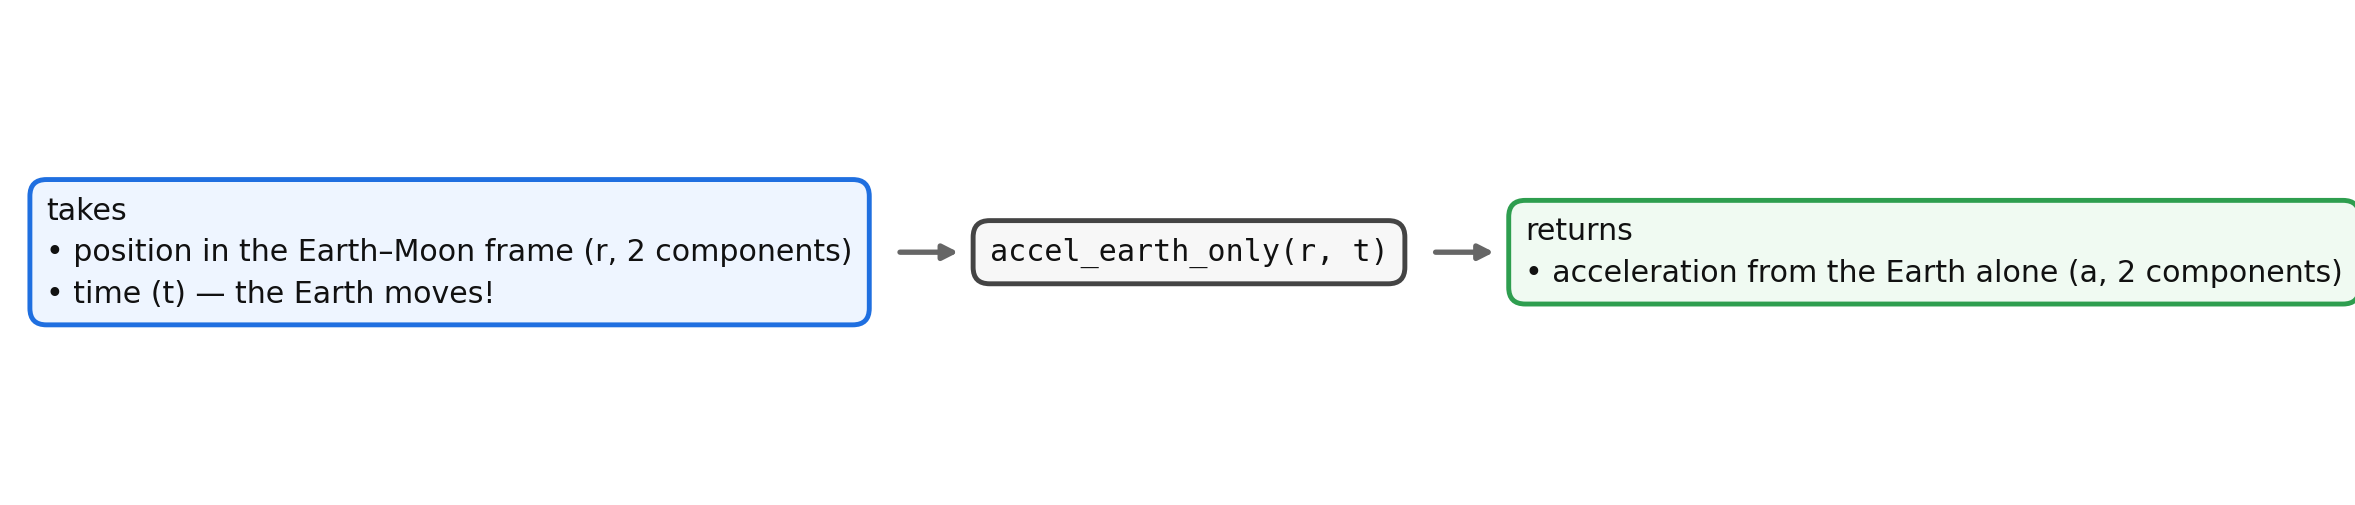

**Stage 2 — add the Moon.** Write `accel_3b(r, t)`: Earth **and** Moon (mass fraction $\mu$, at
`moon_pos(t)`). Same structure, one more term.

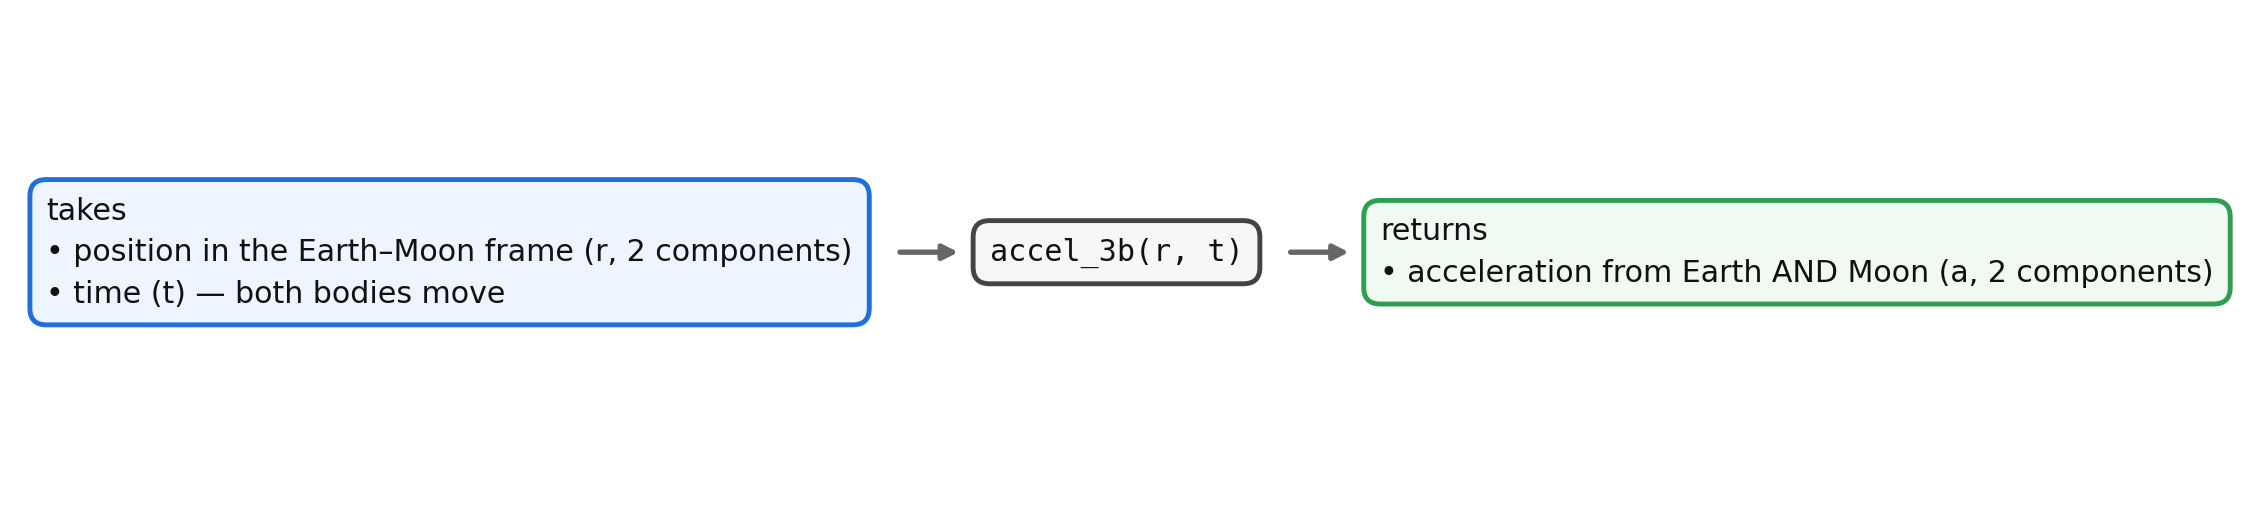

The "fly it" cell below runs both: the Earth-only version is the "no Moon" comparison.

In [ ]:
# Replace this stub with your LLM's code (delete the raise line); keep the function name and signature.
def accel_earth_only(r, t):
    "Stage 1: acceleration from the Earth alone (mass fraction 1-mu, at earth_pos(t))."
    raise NotImplementedError("build me with LLM")

def accel_3b(r, t):
    "Stage 2: acceleration from Earth AND Moon (mass fraction mu, at moon_pos(t))."
    raise NotImplementedError("build me with LLM")

**Fly it — with the Moon vs without.** Same launch, run twice. The difference matters:
the "no Moon" run is a bound Kepler ellipse, so it *also* comes home eventually — Part 1 taught you
that bound orbits are closed; this one returns around day 12. What the flyby buys is a **prompt,
engine-off return**: the Moon bends the path so the crew reenters on day ~8, four days sooner.

In [ ]:
R_on,  V_on  = simulate(accel_3b,         sc0, scv0, dt, nsteps)   # Earth + Moon
R_off, V_off = simulate(accel_earth_only, sc0, scv0, dt, nsteps)   # Earth only (no Moon)
tt    = np.arange(nsteps)*dt
earth = -mu    *np.column_stack([np.cos(tt+phi), np.sin(tt+phi)])
moon  = (1-mu)*np.column_stack([np.cos(tt+phi), np.sin(tt+phi)])

R_earth, R_moon = 6371.0, 1737.0                # km
ENTRY_ALT = 122.0                               # km: the atmospheric entry interface
tau_days  = 1.0/n_moon/86400.0                  # 1 scaled time unit, in days
window_days = nsteps*dt*tau_days
nominal = (v_factor == 1.00) and (moon_phase_offset == 0.00)
d_on  = np.linalg.norm(R_on  - earth, axis=1)*D
d_off = np.linalg.norm(R_off - earth, axis=1)*D
d_mn  = np.linalg.norm(R_on  - moon,  axis=1)*D

# keep the full no-Moon run for the plot and for its own return
R_off_full, d_off_full, tt_full = R_off.copy(), d_off.copy(), tt.copy()

# stop at reentry: the last sample above the entry interface on the way back down
# (skip the first 100 steps so the launch point itself does not count as a "crossing")
hits = np.where(d_on[100:] < R_earth + ENTRY_ALT)[0]
icut = 100 + hits[0] - 1 if len(hits) else nsteps - 1
R_on, V_on, R_off, V_off, tt = R_on[:icut+1], V_on[:icut+1], R_off[:icut+1], V_off[:icut+1], tt[:icut+1]
earth, moon = earth[:icut+1], moon[:icut+1]
d_on, d_off, d_mn = d_on[:icut+1], d_off[:icut+1], d_mn[:icut+1]

plt.figure(figsize=(6,6))
plt.plot(R_off_full[:,0], R_off_full[:,1], 'C1--', lw=1.2, label='no Moon (Earth-only ellipse)')
plt.plot(R_on[:,0],  R_on[:,1],  'C0',   lw=1.4, label='with Moon (free return)')
plt.plot(moon[:,0],  moon[:,1],  'k:', alpha=.5, label='Moon path')
plt.plot(sc0[0], sc0[1], 'g^', ms=9, label='start (post-TLI)'); plt.plot(0,0,'r+', ms=10)
plt.gca().set_aspect('equal'); plt.grid(alpha=.3); plt.legend(fontsize=8)
plt.title('Lunar flyby: home in 8 days instead of 12' if nominal else 'Lunar flyby (detuned run)'); plt.show()

im = d_mn.argmin(); j = 100 + d_off_full[100:].argmin()
own_return = 100 < j < nsteps - 1               # its closest approach is interior to the window (it turned around)
print(f"window      : {window_days:.1f} days simulated")
if d_mn[im] - R_moon < 50_000:
    print(f"lunar flyby : {d_mn[im]-R_moon:8.0f} km over the Moon, at day {tt[im]*tau_days:.1f}   (Artemis II: ~6500 km)")
else:
    print(f"closest to Moon: {d_mn[im]-R_moon:,.0f} km at day {tt[im]*tau_days:.1f} -- no lunar flyby on this run")
if len(hits):
    if nominal and 7.8 < tt[-1]*tau_days < 8.1:
        print(f"reentry     : day {tt[-1]*tau_days:.2f} after TLI (= Apr 11) -- within about an hour of the real Orion splashdown")
    else:
        print(f"reentry     : day {tt[-1]*tau_days:.2f} after TLI (the real mission reentered on day 7.93)")
    if own_return:
        print(f"no-Moon run : still {d_off[-1]:,.0f} km from Earth at that moment; on its own it comes back around day {tt_full[j]*tau_days:.1f}")
    else:
        print(f"no-Moon run : still {d_off[-1]:,.0f} km from Earth at that moment; on its own it does not come back inside this window")
else:
    if nominal:
        print(f"no reentry inside the {window_days:.1f}-day window with the real-mission knobs -- check your accel_3b (physics check below)")
    else:
        print(f"no reentry inside the {window_days:.1f}-day window -- the detuned launch missed its free return")

**Physics check (given).** With the knobs at the real-mission values, your two functions must
reproduce the mission. Stage 1 is checked through the Earth-only run's apogee (a wrong mass fraction or
force law moves it by 10% or more); Stage 2 through the flyby altitude and the reentry day. A wrong
`accel_3b` usually still *runs*, and the fly-it line may even report a plausible-looking reentry, so this
cell is the one that tells you the physics is right.

In [ ]:
if nominal:
    apo = d_off_full.max()
    assert 430_000 < apo < 470_000, f"Stage 1 (accel_earth_only): no-Moon apogee {apo:,.0f} km, expected ~450,000 km"
    print(f"PASS stage 1: the Earth-only run reaches apogee at {apo:,.0f} km (expected ~450,000 km).")
    assert len(hits) and 7.8 < tt[-1]*tau_days < 8.1, "Stage 2 (accel_3b): no reentry near day 7.9 -- check the Moon term"
    fa = d_mn.min() - R_moon
    assert 7000 < fa < 8500, f"Stage 2 (accel_3b): flyby altitude {fa:,.0f} km, expected ~7,760 km"
    print(f"PASS stage 2: flyby {fa:,.0f} km and reentry on day {tt[-1]*tau_days:.2f} -- your accel_3b reproduces the Artemis free return.")
else:
    print("knobs are detuned -- physics check skipped (set v_factor = 1.00 and moon_phase_offset = 0.00 to run it).")

### Watch the flyby (extend your animation)

You animated an orbit in Part 1. Extend it here: show Earth at the center, the **Moon** moving along its orbit, and the **rocket** flying the free return. Use `R_on` (the rocket's path) and `moon` (the Moon's positions), both computed just above. Ask your LLM to help you reuse and extend your Part 1 animation.

In [ ]:
# TODO (build with LLM): animate the flyby.
# Earth at the center, the Moon moving along its orbit, the rocket flying along R_on.
# Reuse/extend your Part 1 animation. (R_on and moon are already computed above.)
# HINTS: R_on has ~17,000 points -- DOWNSAMPLE to ~100 frames (e.g. every 170th point). At full
# resolution the animation takes many minutes to render and hits Colab's ~20 MB embed limit, after
# which frames are silently dropped. If you really need a bigger one:
#     plt.rcParams['animation.embed_limit'] = 50    # MB

### From dimensionless to real units (telemetry)

Convert the run to physical units using the scales **from the calibration cell**: length $D$ (the
Earth–Moon distance *at the epoch*, 396,856 km) and time $1/n_{\rm moon}$. Note that $D$ is about 3%
larger than the textbook average of 384,400 km — the Moon was near apogee that week. Using the textbook
value here would make every converted distance ~3% off. Reuse the arrays the fly-it cell already
computed (`tt`, `V_on`, `earth`, `moon`, `tau_days`) rather than rebuilding a time axis.

In [ ]:
# TODO (build with LLM): convert R_on to physical units and show a telemetry table.
# Reuse what the fly-it cell already computed: tt (scaled time), V_on (scaled velocity), earth and
# moon (the bodies' positions at each time), tau_days, D and n_moon.
#   1 length unit = D km;  1 time unit = 1/n_moon s (= tau_days days);  1 speed unit = D*n_moon km/s.
#   Distances are from the CENTER of each body: |R_on - earth|*D and |R_on - moon|*D (not |R_on|*D,
#   which is the distance from the barycenter, off by up to 4,800 km).
#   The integrator step dt comes from the knobs cell (1e-4) -- do NOT invent a value for it; if you
#   use tt you do not need it at all.  (Do NOT use the textbook 384,400 km here -- see the note above.)
# Show: day, distance from Earth's center [km], distance from the Moon's center [km],
# speed [km/s], as a small pandas table, plus prints of the mission duration and the
# flyby altitude (distance to the Moon minus its radius, 1737 km).
#
# CHECK YOURSELF: your numbers MUST reproduce the ones the check cell below prints (they come
# straight from the fly-it cell). If they differ, something is wrong in the conversion -- stop
# and debug before moving on.
raise NotImplementedError("build me with LLM")

**Telemetry check (given).** Your table must agree with these numbers, which come straight from the
fly-it cell. A mismatch means a wrong scale factor (a made-up `dt`, the textbook 384,400 km, a
time array built from the wrong step). This is the one place a wrong conversion can *look* fine, so
check it.

In [ ]:
if len(hits):
    print(f"expected mission duration    : {tt[-1]*tau_days:.2f} days (TLI to entry interface)")
else:
    print(f"no reentry inside the window -- the table spans the full {window_days:.1f}-day window")
print(f"expected Earth dist. at start: {d_on[0]:,.0f} km (from Earth's center)")
print(f"expected flyby altitude      : {d_mn.min() - R_moon:.0f} km")
print(f"expected speed at start      : {np.linalg.norm(V_on[0])*D*n_moon:.2f} km/s (barycentric frame)")

### Conceptual questions

**Q1.** In Part 1 the spacecraft's energy and angular momentum were conserved. Here the Earth and Moon
*move*, so the force the spacecraft feels is **time-dependent** — even in the "no Moon" run, where Earth
still orbits the barycenter (so the path only *looks* like a closed ellipse; it is not strictly closed).
Explain why the spacecraft's energy *in this inertial frame* is therefore not conserved.

*(Starred, for extra credit: in the frame that co-rotates with the Earth–Moon line, a combination called
the **Jacobi constant** *is* conserved. Look up its definition and say what makes it useful here.)*

*Your answer:*

> 


**Q2.** The defaults fly the real mission. Detune it: try `v_factor` between 0.97 and 1.03, or
`moon_phase_offset` of $\pm 0.01$ and $\pm 0.05$, re-running the cells each time. Watch the flyby
altitude and the reentry verdict. Which detunings still come home promptly? Which one *misses the Moon
entirely yet still returns* — and why is that not a free return? Which one grazes the Moon? Why does a
real lunar mission need such a tight launch window?

*Your answer:*

> 


## Extension (optional) — compare to the real Artemis II

NASA publishes Orion's actual trajectory. Overlay the real flyby on your simulation and note where
the idealized restricted-three-body model differs from reality (the Sun, a non-circular Moon orbit,
maneuvers). *Needs internet; you may have to adjust the query.*

**Build with LLM:** ask your LLM to pull Orion's geocentric trajectory from **JPL Horizons**
(spacecraft id **-1024**), roughly **2026-04-02 to 2026-04-10**, and plot it. Use a 2-hour step (`step='2h'`) to start.

*Two things to expect.* The first day of the window is Orion's pre-TLI orbit near Earth (TLI was on
Apr 2, 23:50 UTC), so the real track starts with a small loop before the outbound leg that your
simulation does not have. And to overlay the real track on your simulation you must move it into the
same frame: fetch the Moon (id `301`) for the same times, form the barycentric position
$\mathbf r - \mu\,\mathbf r_{\rm Moon}$, project onto `e1`, `e2` from the calibration cell, and divide
by `D`.

In [ ]:
# Extension (optional; needs internet). The install line is given -- run this cell once first:
!pip install astroquery -q
# TODO (build with LLM): fetch Orion (id -1024) from JPL Horizons and plot its track.
# Use astroquery.jplhorizons.Horizons with location='500@399' (geocentric), the window
# 2026-04-02 02:00 to 2026-04-10 23:00 (Orion's ephemeris coverage), step '2h'.
# If the install or the fetch fails (no internet, Horizons unavailable), skip this extension.

**A closer look (figure this out).** Your track is probably jagged near Earth but smooth near the Moon.

**Q:** Why? (Hint: `step` is a step in *time* -- where does the spacecraft move fastest?)

**Task:** Reduce `step` until the near-Earth curve is smooth. What value did you need, and does this remind you of anything from Part 1?

*Your answer:*

> 


### Energy detective — when are the engines firing?

In Part 1 you checked that a *coasting* spacecraft conserves energy. A real rocket fires its engine, and
when it does, the energy jumps. **Predict first:** which quantity should you plot to see this? Write the
spacecraft's specific energy in the geocentric frame (kinetic + Earth's gravitational potential). *(It is
the same energy you conserved in Part 1 — now in km and km/s.)*

*Your answer:*

In [ ]:
# TODO (build with LLM): compute and plot the real Orion specific energy vs time.
# Use the ephemeris you fetched above (it has positions AND velocities): E = v^2/2 - GM_E/r,
# with GM_E = 398600.4418 km^3/s^2. Convert AU -> km (1 AU = 1.495978707e8 km) and
# AU/day -> km/s (divide by 86400). Plot E against days from the start of the window.
raise NotImplementedError("build me with LLM")

**Now look.** Where is $E$ flat (coasting, engine off) and where does it jump (engine firing)?
Roughly when is the big trans-lunar-injection burn? And near the lunar flyby $E$ shifts a little even
with the engine off — why? *(Think about Q1: whose gravity is doing work there?)*

*Your answer:*

### See it in 3D (rotatable)

The real trajectory is not planar -- the Moon's orbit is inclined, so Orion moves out of the plane. **Task:** with your LLM, make a rotatable 3D view using Plotly (`plotly.graph_objects.Scatter3d`) -- plot `x, y, z` from the ephemeris you fetched, with Earth at the origin. In Colab, `fig.show()` lets you drag to rotate.

In [ ]:
# TODO (build with LLM): a rotatable 3D Plotly view (Scatter3d) of the real trajectory.
# Plot x, y, z (geocentric) with Earth at the origin. fig.show() is rotatable in Colab.